In [12]:
import numpy as np
import pandas as pd
from itertools import combinations

from popt.config import sect, intn, bond, metl, comd, universe
from popt.config import _2W, _1M, _3M, _6M, _1Y, _2Y, _3Y
from popt.alpha.modules.features import (
    momentum,
    momentum_vs,
    drawdown, 
    volatility, 
    volatility_downside, 
    sharpe_like, 
    skewness,
    kurtosis,
)

from popt.alpha.modules.features import FeatureBuilder, FeatureView
from popt.alpha.modules.predictor import RidgeRanker
from popt.alpha.modules.simulator import AlphaSimulator
from popt.alpha.modules.utils import rank_cs, ic_score

from popt.backtest.modules.backtestdata import DataBuilder, DataLoader
from popt.backtest.modules.strategies import MetaStrategy, FixedWeights, Markowitz, asset_plot
from popt.backtest.modules.simulator import BacktestSimulator, wealth_plot
from popt.backtest.modules.riskmodel import RiskModel

In [2]:
fctr = ["SPY"]
ETF_CATEGORY = sect

TARGET = "mom_1m"
REGRESS = True   # NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE
Z_SCALE = True

LOOKBACK = _1Y
HALFLIFE = np.inf
GAMMA = 1

FIRST_DATE = "2005-01-03"
FINAL_DATE = "2024-12-31"
SPREAD = 5e-4
LEVERAGE = 0.0
VC_LIMIT = 0.08
REBAL_FREQ = "M"

D0 = "1993-01-29"
D1 = "2026-03-24"
riskmodel = RiskModel.load_from_npz("../../data/riskmodel/k10_lb6m_hc6m_hv2m.npz")
rd = pd.read_parquet("../../data/return/return_d.parquet")#.loc[D0:D1]
rf = pd.read_parquet("../../data/return/ffr_d.parquet").reindex(rd.index)
rx = rd - rf.values

bsim = BacktestSimulator(SPREAD)

In [3]:
fb = FeatureBuilder(ret_d=rx, tickers=ETF_CATEGORY, factors=fctr, lookback=_1Y, first_date=D0, final_date=D1)
# add separate methods for adding constant and non-return features (macro and similar?)
# add feature of last days return
# add feature of last weeks returns

fb.add_feature(name="mom_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=momentum)
fb.add_feature(name="mom_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=momentum)
fb.add_feature(name="mom_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=momentum)
fb.add_feature(name="mom_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=momentum)
fb.add_feature(name="mom_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=momentum)
fb.add_feature(name="mom_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=momentum)
fb.add_feature(name="mom_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=momentum)

fb.add_feature(name="mvs_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=momentum_vs)
fb.add_feature(name="mvs_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=momentum_vs)
fb.add_feature(name="mvs_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=momentum_vs)
fb.add_feature(name="mvs_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=momentum_vs)
fb.add_feature(name="mvs_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=momentum_vs)
fb.add_feature(name="mvs_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=momentum_vs)
fb.add_feature(name="mvs_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=momentum_vs)

fb.add_feature(name="mdd_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=drawdown)
fb.add_feature(name="mdd_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=drawdown)
fb.add_feature(name="mdd_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=drawdown)
fb.add_feature(name="mdd_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=drawdown)
fb.add_feature(name="mdd_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=drawdown)
fb.add_feature(name="mdd_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=drawdown)
fb.add_feature(name="mdd_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=drawdown)

fb.add_feature(name="vol_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=volatility)
fb.add_feature(name="vol_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=volatility)
fb.add_feature(name="vol_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=volatility)
fb.add_feature(name="vol_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=volatility)
fb.add_feature(name="vol_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=volatility)
fb.add_feature(name="vol_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=volatility)
fb.add_feature(name="vol_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=volatility)

fb.add_feature(name="skw_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=skewness)
fb.add_feature(name="skw_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=skewness)
fb.add_feature(name="skw_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=skewness)
fb.add_feature(name="skw_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=skewness)
fb.add_feature(name="skw_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=skewness)
fb.add_feature(name="skw_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=skewness)
fb.add_feature(name="skw_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=skewness)

fb.add_feature(name="krt_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=kurtosis)
fb.add_feature(name="krt_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=kurtosis)
fb.add_feature(name="krt_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=kurtosis)
fb.add_feature(name="krt_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=kurtosis)
fb.add_feature(name="krt_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=kurtosis)
fb.add_feature(name="krt_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=kurtosis)
fb.add_feature(name="krt_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=kurtosis)

fb.consolidate()

In [ ]:
# uniform
# uniform + vol control
# inverse volatility = weights (w. / wo. vol coltrol)
# risk parity 

0.3919 0.0853 0.1058 21 [-0.12532221 -0.02821235]


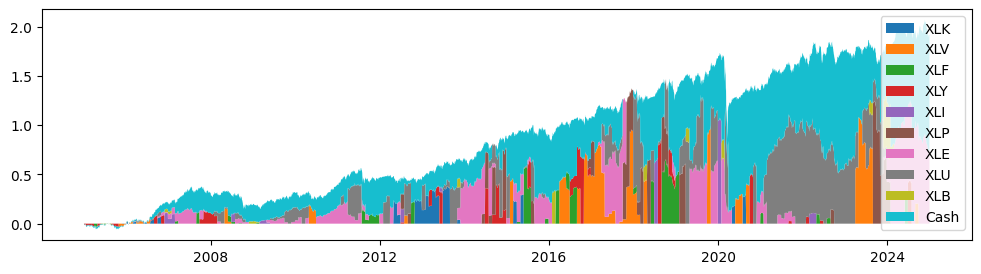

In [59]:
# "skw_1m", "mom_1m"


fv = FeatureView(fb, target=TARGET, subset=["mom_3y", "mom_1m"])

rr = RidgeRanker(lookback=LOOKBACK, halflife=HALFLIFE, gamma=GAMMA)
asim = AlphaSimulator(fv)
asim.run(predictor=rr, permute=False, verbose=False)
alpha = asim.get_alpha(universe, cheat=False, rank=False)

spearm = np.round(np.nanmean(asim.ic_spearman), decimals=4)
pearsn = np.round(np.nanmean(asim.ic_pearson), decimals=4)

# alpha[:] = 1.0
# alpha[:] = np.random.random(alpha.shape)

db = DataBuilder(
    universe=rd.columns,
    first_date=FIRST_DATE,
    final_date=FINAL_DATE,
    alpha=alpha,
    rd=rd,
    rf=rf,
    riskmodel=riskmodel,
    rebal_freq=REBAL_FREQ,
)
dl = DataLoader(db=db, tickers=ETF_CATEGORY)
m = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=0.7*np.ones(dl.N),
    vc_lim=VC_LIMIT,
)
bsim.run(strategy=m, verbose=False)

sharpe = np.round(bsim.ann_sharpe, decimals=4)
print(sharpe, spearm, pearsn, fv.horizon, np.nanmean(asim.thetas, axis=0))

# thetas = asim.thetas[:,i]
# u_theta = np.nanmean(thetas).round(4)
# s_theta = np.nanstd(thetas).round(4)

wealth_plot(bsim)



,XLK,XLV,XLF,XLY,XLI,XLP,XLE,XLU,XLB
Date,,,,,,,,,
2012-12-05,0.181236,-0.053438,-0.192295,-0.026498,-0.022164,0.055817,-0.151342,0.070020,0.138664
2012-12-06,0.208445,-0.043311,-0.170245,-0.010748,0.017074,0.073819,-0.221643,0.059432,0.087177
2012-12-07,0.193491,-0.036699,-0.173370,-0.017363,0.004709,0.058495,-0.199080,0.114039,0.055779
2012-12-10,0.209677,-0.044329,-0.141995,0.013365,-0.019145,0.047200,-0.218582,0.114013,0.039797
2012-12-11,0.202744,-0.038918,-0.154379,0.009401,-0.022106,0.045319,-0.230847,0.125694,0.063093
...,...,...,...,...,...,...,...,...,...
2014-11-21,0.056517,-0.144440,-0.120708,0.007665,0.077348,0.188995,-0.059359,0.006485,-0.012502
2014-11-24,0.069464,-0.156848,-0.087963,0.147590,0.072330,0.128061,-0.015721,-0.107237,-0.049677
2014-11-25,0.045881,-0.184836,-0.137693,0.141232,0.077367,0.102254,0.004478,-0.126650,0.077969


In [5]:
# ref = pd.DataFrame(asim.ref, columns=asim.fv.tickers, index=asim.fv.timeline).dropna()
# ref.describe().T

In [6]:
# sharpes = pd.read_csv("../../.deprecated/bond_2f.csv")
# sharpes.sort_values("spearm", ascending=False).head(25)

In [7]:
# from itertools import combinations
# fv = FeatureView(fb, target="mom_1m", subset=None)
# feature_combinations = combinations(fv.features, r=2)

# for i, (f1, f2) in enumerate(feature_combinations):
#     fv = FeatureView(fb, target="mom_1m", subset=[f1, f2])

#     rr = RidgeRanker(lookback=LOOKBACK, halflife=HALFLIFE, gamma=GAMMA)
#     asim = AlphaSimulator(fv)
#     asim.run(predictor=rr, verbose=False, permute=False)
#     alpha = asim.get_alpha(universe)

#     # alpha[:] = 1.0
#     # alpha[:] = np.random.random(alpha.shape)

#     db = DataBuilder(
#         universe=rd.columns,
#         first_date=FIRST_DATE,
#         final_date=FINAL_DATE,
#         alpha=alpha,
#         rd=rd,
#         rf=rf,
#         riskmodel=riskmodel,
#         rebal_freq=REBAL_FREQ,
#     )
#     dl = DataLoader(db=db, tickers=ETF_CATEGORY)
#     m = Markowitz(
#         dl=dl,
#         lookahead=0,
#         gamma=SPREAD,
#         lev=LEVERAGE,
#         w_max=0.7*np.ones(dl.N),
#         vc_lim=VC_LIMIT,
#     )
#     bsim.run(strategy=m, verbose=False)

#     sharpe = np.round(bsim.ann_sharpe, decimals=4)
#     spearm = np.round(np.nanmean(asim.ic_spearman), decimals=4)
#     pearsn = np.round(np.nanmean(asim.ic_pearson), decimals=4)
#     # thetas = asim.thetas[:,i]
#     # u_theta = np.nanmean(thetas).round(4)
#     # s_theta = np.nanstd(thetas).round(4)

#     print(f1, f2, sharpe, spearm, pearsn)
#     # wealth_plot(bsim)

# # NOTE without rank post processing
# # sect -> 0.5824 0.0168 krt_3y (0.5012)
# # bond -> 0.3687 -0.0375 skw_3y (0.2774)
# # metl -> 0.4892 0.0792 mom_vs_3m (0.3951)
# # intn -> 0.4095 0.0297 mom_2w (0.0854)
# # comd -> -0.0155 -0.0043 mdd_2w (-0.2014)

In [8]:
# alpha = 1    : ...
# random alpha : ...
# alpha perm y : ...

In [9]:
# sharpes = pd.read_csv("../../.deprecated/sect_2f.csv")
# sharpes.sort_values("sharpe", ascending=False).head(25)

# sharpes = pd.read_csv("../../.deprecated/sect_mdd1y_3f.csv")
# sharpes.sort_values("sharpe", ascending=False).head(25)

In [10]:
# N = 500
# sharpes_rand_perm = []
# for i in range(N):
#     fv = FeatureView(fb, target="mom_1m", subset=["skw_2y", "krt_1y"])

#     rr = RidgeRanker(lookback=LOOKBACK, halflife=HALFLIFE, gamma=GAMMA)
#     asim = AlphaSimulator(fv)
#     asim.run(predictor=rr, verbose=False, permute=True)
#     alpha = asim.get_alpha(universe)

#     # alpha[:] = 1.0
#     # alpha[:] = np.random.random(alpha.shape)

#     db = DataBuilder(
#         universe=rd.columns,
#         first_date=FIRST_DATE,
#         final_date=FINAL_DATE,
#         alpha=alpha,
#         rd=rd,
#         rf=rf,
#         riskmodel=riskmodel,
#         rebal_freq=REBAL_FREQ,
#     )
#     dl = DataLoader(db=db, tickers=ETF_CATEGORY)
#     m = Markowitz(
#         dl=dl,
#         lookahead=0,
#         gamma=SPREAD,
#         lev=LEVERAGE,
#         w_max=0.7*np.ones(dl.N),
#         vc_lim=VC_LIMIT,
#     )
#     bsim.run(strategy=m, verbose=False)

#     sharpe = np.round(bsim.ann_sharpe, decimals=4)
#     spearm = np.round(np.nanmean(asim.ic_spearman), decimals=4)
#     pearsn = np.round(np.nanmean(asim.ic_pearson), decimals=4)

#     print(i, sharpe, spearm, pearsn)
#     sharpes_rand_perm.append(sharpe)
#     # wealth_plot(bsim)

# # krt_2w
# # p_val = (1 + np.sum(np.array(sharpes_rand_perm) >= 0.6550)) / (N+1)
# # p_val -> 0.031936127744510975

# # mdd_1y, skw_3m
# # p_val = (1 + np.sum(np.array(sharpes_rand_perm) >= 0.7536)) / (N+1)
# # p_val -> 0.003992015968063872

In [11]:
# periods = [
#     ("2005-01-03", "2014-12-31", "2015-01-03", "2015-12-31"),
#     ("2006-01-03", "2015-12-31", "2016-01-04", "2016-12-30"),
#     ("2007-01-03", "2016-12-30", "2017-01-03", "2017-12-29"),
#     ("2008-01-02", "2017-12-29", "2018-01-02", "2018-12-31"),
#     ("2009-01-02", "2018-12-31", "2019-01-02", "2019-12-31"),
#     ("2010-01-04", "2019-12-31", "2020-01-02", "2020-12-31"),
#     ("2011-01-03", "2020-12-31", "2021-01-04", "2021-12-31"),
#     ("2012-01-03", "2021-12-31", "2022-01-03", "2022-12-30"),
#     ("2013-01-02", "2022-12-30", "2023-01-03", "2023-12-29"),
#     ("2014-01-02", "2023-12-29", "2024-01-02", "2024-12-31"),
# ]

# fb = FeatureBuilder(ret_d=rx, tickers=ETF_CATEGORY, factors=fctr, lookback=_1Y, first_date=d0_trn, final_date=d1_trn)
    # fb.add_feature(name="mom_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=momentum)
    # fb.add_feature(name="mdd_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=drawdown)
    # fb.add_feature(name="skw_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=skewness)
    # fb.add_feature(name="krt_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=kurtosis)
    # fb.consolidate()
FIRST_DATE = "2005-01-03"
FINAL_DATE = "2024-12-31"

periods = (
    ("2005-01-03", "2005-12-30"),
    ("2006-01-03", "2006-12-29"),
    ("2007-01-03", "2007-12-31"),
    ("2008-01-02", "2008-12-31"),
    ("2009-01-02", "2009-12-31"),
    ("2010-01-04", "2010-12-31"),
    ("2011-01-03", "2011-12-30"),
    ("2012-01-03", "2012-12-31"),
    ("2013-01-02", "2013-12-31"),
    ("2014-01-02", "2014-12-31"),
    ("2015-01-02", "2015-12-31"),
    ("2016-01-04", "2016-12-30"),
    ("2017-01-03", "2017-12-29"),
    ("2018-01-02", "2018-12-31"),
    ("2019-01-02", "2019-12-31"),
    ("2020-01-02", "2020-12-31"),
    ("2021-01-04", "2021-12-31"),
    ("2022-01-03", "2022-12-30"),
    ("2023-01-03", "2023-12-29"),
    ("2024-01-02", "2024-12-31"),
)
results = []
for i, (d0_trn, d1_trn) in enumerate(periods):  # , d0_tst, d1_tst
    for f in fb.features:
        fv = FeatureView(fb, target="mom_1m", subset=[f])

        rr = RidgeRanker(lookback=LOOKBACK, halflife=HALFLIFE, gamma=GAMMA)
        asim = AlphaSimulator(fv)
        asim.run(predictor=rr, verbose=False, permute=False)
        alpha = asim.get_alpha(universe)

        db = DataBuilder(
            universe=rd.columns,
            first_date=d0_trn,
            final_date=d1_trn,
            alpha=alpha,
            rd=rd,
            rf=rf,
            riskmodel=riskmodel,
            rebal_freq=REBAL_FREQ,
        )
        dl = DataLoader(db=db, tickers=ETF_CATEGORY)
        m = Markowitz(
            dl=dl,
            lookahead=0,
            gamma=SPREAD,
            lev=LEVERAGE,
            w_max=0.7*np.ones(dl.N),
            vc_lim=VC_LIMIT,
        )
        bsim.run(strategy=m, verbose=False)
        # wealth_plot(bsim)

        sharpe = np.round(bsim.ann_sharpe, decimals=4)
        # spearm = np.round(np.nanmean(asim.ic_spearman), decimals=4)
        # pearsn = np.round(np.nanmean(asim.ic_pearson), decimals=4)
        # spearm, pearsn
        # print(f, d0_trn, d1_trn, sharpe)
        print([d0_trn[:4], sharpe.item(), f])
        results.append([d0_trn[:4], sharpe.item(), f])
results
# We are NOT asking: Does this rank assets correctly? (IC ≈ 0, negative sometimes)
# Sharpe survives / even improved on flipped alpha
# We are asking: Does this signal improve timing of exposure to the ETF?

pd.DataFrame(results, columns=["year", "sharpe", "feature"]).to_csv("../../.deprecated/top5.csv", index=False)

['2005', -0.1038, 'mom_2w']
['2005', 0.3498, 'mom_1m']
['2005', 0.9756, 'mom_3m']
['2005', 1.0724, 'mom_6m']
['2005', 0.1921, 'mom_1y']
['2005', -0.0348, 'mom_2y']
['2005', -0.4195, 'mom_3y']
['2005', -0.6356, 'mvs_2w']
['2005', 0.0521, 'mvs_1m']
['2005', 0.5449, 'mvs_3m']
['2005', 0.8304, 'mvs_6m']
['2005', 0.0798, 'mvs_1y']
['2005', -0.1009, 'mvs_2y']
['2005', 0.2746, 'mvs_3y']
['2005', 0.0619, 'mdd_2w']
['2005', 0.5648, 'mdd_1m']
['2005', 0.7424, 'mdd_3m']
['2005', 1.5814, 'mdd_6m']
['2005', 2.2367, 'mdd_1y']
['2005', 1.0226, 'mdd_2y']
['2005', 0.737, 'mdd_3y']
['2005', 1.5791, 'vol_2w']
['2005', 0.7188, 'vol_1m']
['2005', 1.0489, 'vol_3m']
['2005', 0.4459, 'vol_6m']
['2005', 0.5262, 'vol_1y']
['2005', 0.6444, 'vol_2y']
['2005', 1.1759, 'vol_3y']
['2005', 1.1556, 'skw_2w']
['2005', 1.9312, 'skw_1m']
['2005', 0.6131, 'skw_3m']
['2005', 0.1586, 'skw_6m']
['2005', 0.446, 'skw_1y']
['2005', -0.235, 'skw_2y']
['2005', 0.915, 'skw_3y']
['2005', 0.7754, 'krt_2w']
['2005', 0.4278, 'krt_1m']

KeyboardInterrupt: 

[]

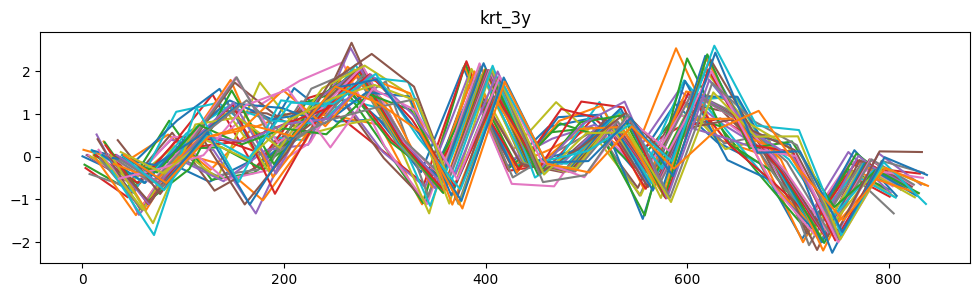

In [ ]:
import matplotlib.pyplot as plt

top5 = pd.read_csv("../../.deprecated/top5.csv")
for f in top5["feature"].unique():
    top5.loc[top5["feature"] == f, "sharpe"].plot(figsize=(12,3), title=f)
plt.plot()

In [ ]:
q25 = lambda x: x.quantile(0.25)
q75 = lambda x: x.quantile(0.75)
q25.__name__ = "q25"
q75.__name__ = "q75"

(
    top5
    .groupby("feature")
    .aggregate({
        "sharpe": [
            "mean", 
            "std", 
            "min",
            q25,
            "median", 
            q75,
            "max"]
        })
    .sort_values(by=("sharpe", "mean"), ascending=False)
)

sharpe                                                       
             mean       std     min       q25   median       q75     max
feature                                                                 
krt_2w   0.401100  1.149142 -1.7495 -0.104750  0.20760  1.178175  2.4102
krt_1y   0.357860  1.073270 -1.8331 -0.108800  0.29320  0.875325  2.6029
skw_3y   0.356495  1.005634 -1.8548 -0.330675  0.41610  0.915350  1.9988
skw_3m   0.350885  1.078332 -2.2502 -0.225025  0.36870  1.165375  2.3653
skw_2y   0.325490  1.021441 -1.9603 -0.313175  0.26120  1.136200  2.0468
skw_1y   0.320405  0.947938 -1.1796 -0.379550  0.32500  0.847675  2.3995
mdd_3y   0.319545  1.061235 -1.9994 -0.385350  0.18690  1.110975  2.1921
skw_1m   0.319145  1.183945 -1.8349 -0.512350  0.04115  1.220675  2.1331
skw_2w   0.318895  1.207481 -1.6510 -0.531625  0.22700  1.143075  2.1371
vol_2y   0.308020  1.024299 -1.7697 -0.402550  0.18155  0.898375  2.1244
mdd_2y   0.307080  1.023285 -1.9960 -0.386250  0.18690  0.940775  2.1569
skw_6m   0.305305  1.072426 -1.6656 -0.526800  0.43805  0.882425  2.3053
krt_1m   0.305070  1.014188 -2.0037 -0.378700  0.08845  1.124050  2.0030
vol_1y   0.302765  1.070409 -1.8764 -0.403950  0.20065  0.997725  2.1470
vol_3y   0.285115  0.991733 -1.7717 -0.401600  0.07830  0.828050  2.0344
mom_1m   0.272940  1.010056 -2.0024 -0.266875  0.16160  0.706275  2.5424
mvs_6m   0.263190  1.010962 -1.6763 -0.404900  0.14955  0.942700  1.7783
krt_6m   0.258320  1.007422 -1.9366 -0.392475  0.43340  0.984800  1.7175
mom_3y   0.250655  1.003201 -1.5219 -0.619050  0.17390  0.892750  2.2117
mdd_6m   0.245880  1.069108 -1.6547 -0.466050 -0.07900  1.094875  2.1090
krt_3m   0.245485  1.016780 -1.9348 -0.472250  0.33125  1.023700  1.7317
krt_2y   0.238155  1.076581 -1.7622 -0.432425  0.06650  0.657450  2.4408
mvs_3y   0.237155  0.872706 -1.5186 -0.446025  0.15305  0.935600  1.6704
mvs_3m   0.235220  1.001934 -1.6051 -0.513000  0.27270  1.137600  1.7892
vol_1m   0.216090  1.085722 -2.0197 -0.365775 -0.14030  1.009575  2.0452
vol_6m   0.206975  1.057973 -1.8764 -0.452000 -0.03725  0.947550  2.0473
krt_3y   0.200085  0.888398 -1.4903 -0.351375  0.25540  0.721025  1.7584
mdd_1y   0.193670  1.040826 -1.8432 -0.437275 -0.03495  1.017400  2.0473
mdd_1m   0.191245  1.066235 -2.1833 -0.427375  0.16745  0.878025  2.6716
mom_1y   0.179400  0.890629 -1.5108 -0.219900  0.13795  0.749775  1.8426
mvs_2y   0.179165  0.989644 -1.6397 -0.357825  0.13315  0.540025  2.3040
mvs_1m   0.177780  1.017093 -1.8580 -0.510675  0.21750  0.801475  2.0598
vol_2w   0.176700  1.072572 -2.1978 -0.397425  0.13800  0.818575  2.0446
mvs_1y   0.171735  1.101343 -1.6140 -0.637025 -0.05270  1.187475  2.1102
mom_6m   0.167395  0.893434 -1.4432 -0.346700  0.13410  0.863575  2.2386
mom_2w   0.164285  0.920613 -1.9294 -0.334900 -0.10135  0.837500  2.0915
vol_3m   0.160140  1.053515 -1.8764 -0.642775  0.06880  0.872650  2.0320
mom_3m   0.096615  0.948996 -1.6425 -0.496625 -0.21410  0.690425  2.1804
mdd_3m   0.085560  1.030131 -1.9156 -0.575350 -0.16055  0.641400  2.1882
mdd_2w   0.082105  0.975147 -1.7900 -0.584925  0.03385  0.564800  2.5531
mvs_2w   0.045090  1.045747 -2.0725 -0.547600 -0.12965  0.772150  1.7651
mom_2y   0.043940  0.879931 -1.8000 -0.499425 -0.09515  0.577075  1.6836

In [53]:
#               A     B     C       D
r = np.array([-0.03, -0.2, -0.05, -0.04])

(r - r.mean() )/ r.std()

array([ 0.71795816, -1.72309958,  0.4307749 ,  0.57436653])